In [1]:
%matplotlib widget

In [ ]:
import cv2
import os
import glob
import matplotlib.pyplot as plt
from IPython.display import display
import pandas as pd



Found 5 AVI files.


In [4]:
avi_dir = "/fs/vulcan-projects/fsh_track/data/autumn"  # change to your directory path
avi_files = sorted(glob.glob(os.path.join(avi_dir, "*.avi")))
output_data = []

print(f"Found {len(avi_files)} AVI files.")

Found 5 AVI files.


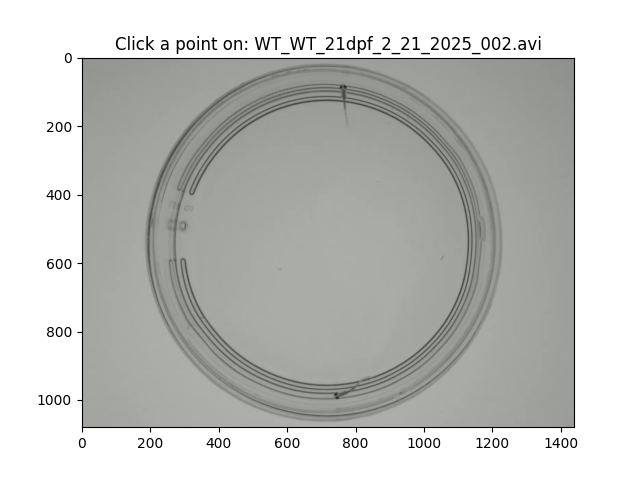

In [7]:
# Run this for each video to collect a point

if avi_files:
    video_path = avi_files.pop(0)  # Get one file and remove it from the list
    cap = cv2.VideoCapture(video_path)
    ret, frame = cap.read()
    cap.release()

    if not ret:
        print(f"Could not read from {video_path}")
    else:
        coords = []

        fig, ax = plt.subplots()
        ax.set_title(f"Click a point on: {os.path.basename(video_path)}")
        img = ax.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

        def onclick(event):
            if event.xdata and event.ydata:
                x, y = int(event.xdata), int(event.ydata)
                coords.append((x, y))
                output_data.append((os.path.basename(video_path), x, y))
                print(f"Selected: {x}, {y} on {os.path.basename(video_path)}")
                fig.canvas.mpl_disconnect(cid)
                plt.close()

        cid = fig.canvas.mpl_connect('button_press_event', onclick)
        plt.show()
else:
    print("✅ All videos processed!")

In [8]:
df = pd.DataFrame(output_data, columns=["filename", "x", "y"])
df.to_csv("selected_points.tsv", sep="\t", index=False)
print("✅ Saved to selected_points.tsv")

✅ Saved to selected_points.tsv
